[*********************100%***********************]  1 of 1 completed


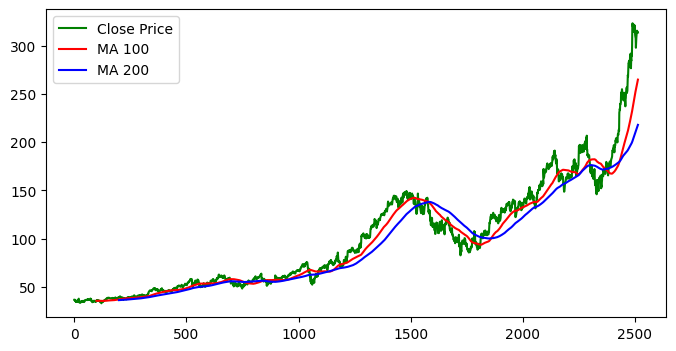

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 334ms/step - loss: 0.0180
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 327ms/step - loss: 0.0057
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 326ms/step - loss: 0.0051
Epoch 4/20
 5/60 ━━━━━━━━━━━━━━━━━━━━ 17s 319ms/step - loss: 0.0068

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential


start = '2016-01-01'
end = '2026-01-01'

data = yf.download('GOOG', start=start, end=end)

data.reset_index(inplace=True)
data.dropna(inplace=True)

#moving avg
ma_100 = data.Close.rolling(100).mean()
ma_200 = data.Close.rolling(200).mean()

plt.figure(figsize=(8,4))
plt.plot(data.Close, 'g', label='Close Price')
plt.plot(ma_100, 'r', label='MA 100')
plt.plot(ma_200, 'b', label='MA 200')
plt.legend()
plt.show()

#train-test-split
data_train = pd.DataFrame(data.Close[0:int(len(data)*0.80)])
data_test = pd.DataFrame(data.Close[int(len(data)*0.80):])

#  SCALING

scaler = MinMaxScaler(feature_range=(0,1))
data_train_scale = scaler.fit_transform(data_train)

#  CREATE DATASET (TRAIN)

x_train = []
y_train = []

for i in range(100, data_train_scale.shape[0]):
    x_train.append(data_train_scale[i-100:i])
    y_train.append(data_train_scale[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

# BUILD MODEL

model = Sequential()

model.add(LSTM(units=50, activation='tanh', return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='tanh', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='tanh', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='tanh'))
model.add(Dropout(0.5))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# TRAIN MODEL

model.fit(x_train, y_train, epochs=20, batch_size=32, verbose=1)

#  PREPARE TEST DATA

past_100_days = data_train.tail(100)
data_test = pd.concat([past_100_days, data_test], ignore_index=True)

# ONLY transform (NO fit_transform)
data_test_scale = scaler.transform(data_test)

# CREATE TEST DATASET

x_test = []
y_test = []

for i in range(100, data_test_scale.shape[0]):
    x_test.append(data_test_scale[i-100:i])
    y_test.append(data_test_scale[i,0])

x_test, y_test = np.array(x_test), np.array(y_test)

#  PREDICTION

y_predict = model.predict(x_test)

# INVERSE SCALING

y_predict = scaler.inverse_transform(y_predict)
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

#  PLOT RESULT

plt.figure(figsize=(10,8))
plt.plot(y_test, 'g', label='Original Price')
plt.plot(y_predict, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

#  SAVE MODEL

model.save("fixed_model.keras")